In [1]:
import numpy as np
import matplotlib.pyplot as plt

from CBSetup import *
from myutils import *
from simulator import *

In [2]:
Setup=CBSetup()
def setuptask9(Gb=50, Gs=1, C=1, Cg=0.01):
    #First we create the setup
    #two leads
    Setup.add_lead('LeadLeft')
    Setup.add_lead('LeadRight')

    #two islands
    Setup.add_island('Island1')
    Setup.add_island('Island2')

    #We connect the leads to the islands with 3 tunnel junctions
    Setup.add_junctionBIL('Junction1','Island1','LeadLeft',Gb,C)
    Setup.add_junctionBTI('Junction2','Island1','Island2',Gb,C)
    Setup.add_junctionBIL('Junction3','Island2','LeadRight',Gs,C)

    #We add gates to the islands
    Setup.add_gate('Gate_1', 'Island1', Cg)
    Setup.add_gate('Gate_2', 'Island2', Cg)

    Setup.finish()

In [3]:
Setup=CBSetup()
setup = setuptask9(Gb=200)

Volt_LeadLeft = 1
Volt_LeadRight = 0
Volt_Gate_1 = 0
Volt_Gate_2 = 0

#Setting initial voltages
Setup.set_lead_voltage('LeadLeft',Volt_LeadLeft)
Setup.set_lead_voltage('LeadRight',Volt_LeadRight)
Setup.set_gate_voltage('Gate_1',Volt_Gate_1)
Setup.set_gate_voltage('Gate_2',Volt_Gate_2)

#Setting temperature
Setup.temperature = 10e-3

#Functions to analyse/run the system:
#Setup.give_a_run(debug = 'True')
#Setup.runit()
#Setup.sorted_cache()
#Setup.simulator.movie_theater('Data_testrun1')

In [5]:
#let us take an I-Vcurve from 0 to 20 with 1000 steps, time interval 1000. Took about 15 min for N=8 T=0.27
zeros=np.zeros(2)
Vmax=20.0
Numsteps=100
voltages=np.linspace(0,Vmax, num=Numsteps+1)
# a long run of simulation cycles
listofcurrents=Setup.runit(Numsteps,np.array([0,0]),zeros,np.array([Vmax/2,-Vmax/2]),zeros,timeinterval=1000,debug=True)
listofcurrents = np.array(listofcurrents)

Run 1
CPU time: 0.0 Simulated time: 2450446138213.7 Events: 39 Cache: 39
Run 2
CPU time: 0.0 Simulated time: 2310385595.9 Events: 3 Cache: 3
Run 3
CPU time: 0.0 Simulated time: 19641808.8 Events: 3 Cache: 3
Run 4
CPU time: 0.0 Simulated time: 9892.6 Events: 3 Cache: 3
Run 5
CPU time: 0.0 Simulated time: 1017.8 Events: 122 Cache: 4
Run 6
CPU time: 0.0 Simulated time: 1001.8 Events: 1755 Cache: 7
Run 7
CPU time: 0.0 Simulated time: 1000.9 Events: 1965 Cache: 6
Run 8
CPU time: 0.1 Simulated time: 1000.4 Events: 2394 Cache: 7
Run 9
CPU time: 0.1 Simulated time: 1000.4 Events: 2553 Cache: 6
Run 10
CPU time: 0.1 Simulated time: 1003.8 Events: 2862 Cache: 10
Run 11
CPU time: 0.1 Simulated time: 1000.9 Events: 4523 Cache: 7
Run 12
CPU time: 0.1 Simulated time: 1000.1 Events: 5166 Cache: 8
Run 13
CPU time: 0.1 Simulated time: 1000.5 Events: 5508 Cache: 7
Run 14
CPU time: 0.1 Simulated time: 1001.1 Events: 5460 Cache: 12
Run 15
CPU time: 0.1 Simulated time: 1001.2 Events: 5884 Cache: 10
Run 16
C

KeyboardInterrupt: 

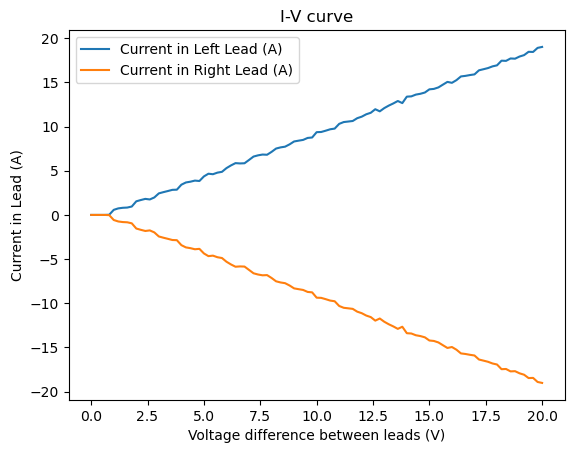

In [10]:
plt.plot(voltages,listofcurrents[:,0], label = 'Current in Left Lead (A)')
plt.plot(voltages,listofcurrents[:,1], label = 'Current in Right Lead (A)')

plt.xlabel('Voltage difference between leads (V)')
plt.ylabel('Current in Lead (A)')
plt.title('I-V curve')
plt.legend()
plt.show()
